# Predicting the Outcome of the 2016 USA Presidential Election

First we install the required libraries.

In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scipy

Then import required libraries, Pandas is used for data manipulation and analysis, NumPy provides support for numerical computations, Matplotlib enables data visualization through plots, Seaborn enhances statistical graphics with a more aesthetically pleasing interface, and SciPy's norm module helps with statistical functions related to the normal distribution.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

## Part 1

This function estimates the confidence interval for a proportion using bootstrapping with a binomial distribution. It generates multiple random samples based on the given proportion (p_hat) and sample size (N), computes their means, and then calculates the standard error. Using a z-score of 1.96 (corresponding to a 95% confidence level), it determines the margin of error and constructs the confidence interval by adding and subtracting this margin from the sample mean. The function returns the lower and upper bounds of the confidence interval.

In [5]:
def compute_confidence_interval(p_hat, N, confidence_level=0.95, iterations=100):
    sample_proportions = []
    for _ in range(iterations):
        sample = np.random.binomial(1, p_hat, N)  
        sample_proportion = np.mean(sample)
        sample_proportions.append(sample_proportion)
    sample_proportions = np.array(sample_proportions)

    sample_mean = np.mean(sample_proportions)
    
    sample_se = np.std(sample_proportions) / np.sqrt(iterations)
    
    z_score = 1.96  
    margin_of_error = z_score * sample_se

    CI_lower = sample_mean - margin_of_error
    CI_upper = sample_mean + margin_of_error

    return CI_lower, CI_upper

## Part 2

This code sets p_hat (the estimated proportion) to 0.47, the sample size N to 30, and the number of iterations for bootstrapping to 100,000. It then calls the compute_confidence_interval function to estimate the 95% confidence interval for the proportion, storing the lower and upper bounds in CI_lower and CI_upper. Finally, it prints the confidence interval formatted to four decimal places.

In [6]:
p_hat = 0.47 
N = 30 
iterations = 100000 

CI_lower, CI_upper = compute_confidence_interval(p_hat, N, iterations=iterations)
print(f"95% Confidence Interval: ({CI_lower:.4f}, {CI_upper:.4f})")


95% Confidence Interval: (0.4700, 0.4711)


## Part 3

This code reads a CSV file containing polling data from the 2016 U.S. presidential election into a Pandas DataFrame. It selects specific columns of interest, including polling percentages for Trump and Clinton, the pollster's name, the start date of the poll, the number of observations (sample size), and the mode of polling (e.g., online, phone). It then removes any rows where the "Number of Observations" column has missing values and prints the first few rows of the cleaned DataFrame.

In [7]:
file_path = '2016-general-election-trump-vs-clinton.csv' 
df = pd.read_csv(file_path)
columns_of_interest = ['Trump', 'Clinton', 'Pollster', 'Start Date', 'Number of Observations', 'Mode']

df_filtered = df[columns_of_interest]

df_filtered = df_filtered.dropna(subset=['Number of Observations'])

print(df_filtered.head())

   Trump  Clinton          Pollster  Start Date  Number of Observations  \
0   41.0     45.0     Insights West  2016-11-04                   940.0   
4   43.0     41.0          IBD/TIPP  2016-11-04                  1107.0   
5   41.0     45.0  YouGov/Economist  2016-11-04                  3669.0   
6    6.0     90.0  YouGov/Economist  2016-11-04                  1392.0   
7   84.0      4.0  YouGov/Economist  2016-11-04                  1110.0   

         Mode  
0    Internet  
4  Live Phone  
5    Internet  
6    Internet  
7    Internet  


## Part 4

This code processes and visualizes polling data for Trump and Clinton over time. It converts the "Start Date" column to a datetime format and represents it numerically as days since January 1, 1970. Using Seaborn's regplot, it plots trend lines (without scatter points) for both Trump (in red) and Clinton (in blue) to show how their support changed over time. The x-axis represents the date, with formatted tick labels for readability, and the y-axis represents the support percentage. Finally, the plot is displayed with a title and proper layout adjustments.

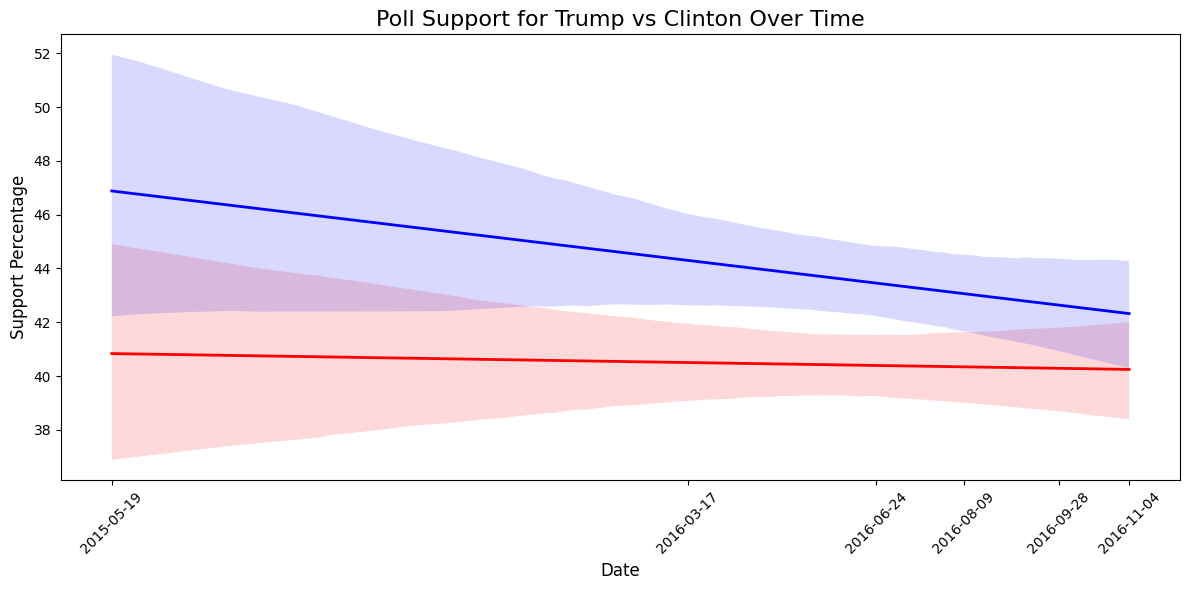

In [ ]:
df_filtered['Start Date'] = pd.to_datetime(df_filtered['Start Date'])

df_filtered['Start Date Numeric'] = (df_filtered['Start Date'] - pd.Timestamp('1970-01-01')) // pd.Timedelta('1D')

plt.figure(figsize=(12, 6))

sns.regplot(x='Start Date Numeric', y='Trump', data=df_filtered, scatter=False, color='red', line_kws={'color': 'red', 'lw': 2})
sns.regplot(x='Start Date Numeric', y='Clinton', data=df_filtered, scatter=False, color='blue', line_kws={'color': 'blue', 'lw': 2})

plt.title('Poll Support for Trump vs Clinton Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Support Percentage', fontsize=12)

xticks_numeric = df_filtered['Start Date Numeric'][::int(len(df_filtered)/5)]
xticks_labels = pd.to_datetime(xticks_numeric, origin='unix', unit='D').dt.strftime('%Y-%m-%d') 

plt.xticks(ticks=xticks_numeric, labels=xticks_labels, rotation=45)

plt.tight_layout()
plt.show()

## Part 5

This code calculates the total number of voters surveyed across all polls by summing the "Number of Observations" column while ignoring missing values. It then prints the total count in a formatted string.

In [9]:
total_observations = df['Number of Observations'].dropna().sum()

print(f"Total number of voters observed: {total_observations}")

Total number of voters observed: 1940931.0


## Part 6

This code calculates the weighted estimated proportions of support for Trump and Clinton based on polling data. It first filters the dataset to include only relevant columns and removes rows with missing values in "Number of Observations." It then converts the support percentages for both candidates into proportions. Using weighted sums, it multiplies each candidate’s proportion by the respective number of observations and sums them up. The final estimated proportions are obtained by dividing these weighted sums by the total number of observations. The results are stored in a DataFrame and printed.

In [10]:
df_filtered = df[['Trump', 'Clinton', 'Number of Observations']]

df_filtered = df_filtered.dropna(subset=['Number of Observations'])

df_filtered['Trump Proportion'] = df_filtered['Trump'] / 100
df_filtered['Clinton Proportion'] = df_filtered['Clinton'] / 100

weighted_trump = (df_filtered['Trump Proportion'] * df_filtered['Number of Observations']).sum()
weighted_clinton = (df_filtered['Clinton Proportion'] * df_filtered['Number of Observations']).sum()

total_observations = df_filtered['Number of Observations'].sum()

estimated_trump_proportion = weighted_trump / total_observations
estimated_clinton_proportion = weighted_clinton / total_observations

results = pd.DataFrame({
    'Candidate': ['Trump', 'Clinton'],
    'Estimated Proportion': [estimated_trump_proportion, estimated_clinton_proportion]
})

print(results)

  Candidate  Estimated Proportion
0     Trump              0.405834
1   Clinton              0.456121


## Part 7

This code computes confidence intervals for the estimated proportions of support for Trump and Clinton. Using the previously calculated `estimated_trump_proportion` and `estimated_clinton_proportion`, it calls the `compute_confidence_interval` function with the total number of observations to generate confidence intervals for both candidates. The results, including the estimated proportions and their respective confidence interval bounds, are stored in a DataFrame and printed.

In [11]:
CI_trump = compute_confidence_interval(estimated_trump_proportion, int(total_observations))
CI_clinton = compute_confidence_interval(estimated_clinton_proportion, int(total_observations))

results = pd.DataFrame({
    'Candidate': ['Trump', 'Clinton'],
    'Estimated Proportion': [estimated_trump_proportion, estimated_clinton_proportion],
    'CI Lower': [CI_trump[0], CI_clinton[0]],
    'CI Upper': [CI_trump[1], CI_clinton[1]]
})

print(results)

  Candidate  Estimated Proportion  CI Lower  CI Upper
0     Trump              0.405834  0.405732  0.405887
1   Clinton              0.456121  0.456127  0.456245


## Part 8


### a

This code calculates the estimated spread (difference in support) between Clinton and Trump, assuming a two-candidate race. The spread is defined as 2 * estimated_clinton_proportion - 1, which represents Clinton's advantage over a 50-50 split. The standard error (SE_p) for Clinton’s proportion is computed using the binomial formula, and the standard error of the spread (SE_d) is derived by scaling SE_p by 2. A margin of error is then determined using a z-score of 1.96 for a 95% confidence level. Finally, the lower and upper bounds of the confidence interval for the spread are calculated and printed.

In [12]:
estimated_spread = 2 * estimated_clinton_proportion - 1

SE_p = np.sqrt((estimated_clinton_proportion * (1 - estimated_clinton_proportion)) / total_observations)
SE_d = 2 * SE_p
margin_of_error_spread = 1.96 * SE_d

CI_spread_lower = estimated_spread - margin_of_error_spread
CI_spread_upper = estimated_spread + margin_of_error_spread

print(f"Estimated Spread (d): {estimated_spread:.4f}")
print(f"95% Confidence Interval for the Spread: ({CI_spread_lower:.4f}, {CI_spread_upper:.4f})")

Estimated Spread (d): -0.0878
95% Confidence Interval for the Spread: (-0.0892, -0.0864)


### b

This code performs a hypothesis test to determine whether the estimated spread (Clinton vs. Trump) is significantly different from zero. The test statistic is calculated by dividing the estimated spread by its standard error (`SE_d`). The p-value is then computed using the cumulative distribution function (CDF) of the normal distribution, applying a two-tailed test. If the p-value is smaller than the significance level (`alpha = 0.05`), the null hypothesis (that the spread is zero) is rejected, indicating a significant difference. Otherwise, the null hypothesis is not rejected, meaning the spread is not statistically significant.

In [13]:
test_statistic = estimated_spread / SE_d

p_value = 2 * (1 - norm.cdf(abs(test_statistic)))

alpha = 0.05  
if p_value < alpha:
    print("Reject the null hypothesis: The spread is significantly different from zero.")
else:
    print("Fail to reject the null hypothesis: The spread is not significantly different from zero.")

Reject the null hypothesis: The spread is significantly different from zero.
